## Introduction

L'approximation des petits angles est un concept clé dans l'étude des systèmes oscillants, et elle joue un rôle crucial dans la simplification des équations de mouvement pour de nombreux phénomènes physiques. Dans le cas du pendule simple, un système oscillant typique, cette approximation permet de linéariser l'équation du mouvement, ce qui facilite son analyse et sa résolution numérique. En effet, pour de petits déplacements angulaires, l'approximation sin(θ) ≈ θ transforme une équation non linéaire en une équation linéaire, plus facile à traiter. Ce type d'approche est particulièrement utile dans le contexte de systèmes amortis, où le frottement influence la dynamique du mouvement. L'analyse de ces systèmes, en fonction du coefficient de frottement, permet de distinguer différents régimes dynamiques, tels que l'oscillation pseudo-périodique, l'amortissement critique ou l'amortissement apériodique. La résolution numérique de ces équations, notamment via la méthode de Runge-Kutta, permet de visualiser ces différents comportements au fil du temps et d'approfondir la compréhension de la dynamique des pendules simples en présence d'amortissement.

### Résolution du problème

Nous cherchons à résoudre numériquement l’équation $\frac{\mathrm{d}^{2}\theta}{\mathrm{d}t^{2}}+q\frac{\mathrm{d}\theta}{\mathrm{d}t}+\Omega^{2}\theta=0$. 
  
La méthode d'Euler vu dans le calepin de cours consiste a approximer la fonction par des segments de droite, en utilisant la décomposition de la fonction par la formule de Taylor au premier ordre. Cette solution est simple à programmer mais est toutefois peu précise au-delà des temps courts. Il existe de nombreuses méthodes pour y remédier. Une classe de méthodes couramment utilisées est la classe des méthodes de Runge-Kutta présentées ci-dessous. Nous nous cantonerons à la méthode de Runge-Kutta 4. 

#### Méthode de Runge-Kutta (explicite) d'ordre 4 (RK4)  
Considérons les équations différentielles ordinaires d'ordre 1 de la forme :  

$$
u'(t) = F(u,t)
$$

avec une condition initiale :  

$$
u(0) = U_0
$$

où $u$ est une quantité scalaire ou vectorielle.  

L'intégration de l'EDO entre $t_k$ et $t_{k+1}= t_k+\Delta t$ donne formellement :  

$$
u(t_{k+1})-u(t_k) = \int_{t_k}^{t_k+\Delta t} \, F(u(t),t)\,\text{d}t
$$

Dans la méthode d'Euler explicite, l'intégrale est approximée par :  

$$
\int_{t_k}^{t_k+\Delta t} \, F(u(t),t)\,\text{d}t = F(u(t_k),t_k) \Delta t
$$

À chaque pas, l'erreur est de l'ordre de $M(\Delta t)^2/2$ où $M$ est l'ordre de grandeur de la dérivée de $F$ par rapport à $t$. Au bout de $N$ pas d'intégration, l'erreur cumulée est donc de l'ordre de $\Delta t$, ce qui en fait une méthode d'ordre 1. Pour améliorer la précision, on utilise des méthodes plus avancées, comme la **méthode de Runge-Kutta d'ordre 4 (RK4)**.  

La méthode RK4 repose sur une estimation plus précise de l'intégrale en combinant plusieurs évaluations de $F$ :  

$$
d_1 =   F\left(t_k   , u_{k} \right)          
$$

$$
d_2 =   F\left(t_k + \frac{\Delta t}{2}  , u_{k} + \frac{\Delta t}{2} d_1 \right)
$$

$$
d_3 =   F\left(t_k + \frac{\Delta t}{2}  , u_{k} + \frac{\Delta t}{2} d_2 \right) 
$$

$$
d_4 =   F\left(t_k + \Delta t  , u_{k} + \Delta t d_3\right)            
$$

$$
u_{k+1} =  u_k  +  \frac{\Delta t}{6} \left[ d_1+ 2 d_2  + 2 d_3 + d_4 \right]
$$

où l'erreur par pas est d'ordre $\Delta t^5$ et l'erreur cumulée est d'ordre $\Delta t^4$, garantissant une bien meilleure précision que la méthode d’Euler.  

#### Application à la résolution du problème du pendule amorti  
Nous appliquons maintenant cette méthode pour résoudre l’équation du mouvement du pendule amorti :  

$$
\frac{\mathrm{d}^{2}\theta}{\mathrm{d}t^{2}} + q\frac{\mathrm{d}\theta}{\mathrm{d}t} + \Omega^{2} \sin\theta = 0
$$

1. **Transformation en un système du premier ordre**  
   Nous reformulons cette équation en un système du premier ordre en posant $\omega = \frac{\mathrm{d}\theta}{\mathrm{d}t}$, ce qui donne :  

   $$
   \frac{\mathrm{d}\theta}{\mathrm{d}t} = \omega, \quad \frac{\mathrm{d}\omega}{\mathrm{d}t} = -q\omega - \Omega^2 \sin\theta
   $$

2. **Application de RK4**  
   Nous appliquons RK4 pour approximer numériquement $\theta$ et $\omega$ à chaque instant $t$ avec un pas de temps $\Delta t$.  

3. **Analyse des régimes**  
   Pour différentes valeurs du coefficient d’amortissement $q$, nous analysons les régimes pseudo-périodique ($q=1$), critique ($q=2$) et apériodique ($q=5$). Enfin, nous traçons sur un même graphique l’évolution de $\theta(t)$ pour observer les différents comportements dynamiques du pendule.


In [31]:
# Importation des modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [32]:
# Définition de la fonction de résolution numérique d'une EDO d'ordre 2 par la méthode d'Euler
def Euler(start, end, step, v_ini, derivee):
    '''
        Application de la méthode d'Euler
    '''
    # Création du tableau temps
    interval = end - start                     # Intervalle
    num_points = int(interval / step) + 1      # Nombre d'éléments
    t = np.linspace(start, end, num_points)    # Tableau temps t

    # Initialisation du tableau v
    v = np.empty((2, num_points))

    # Condition initiale
    v[:, 0] = v_ini 

    # Boucle for
    for i in range(num_points - 1):
        v[:, i + 1] = v[:, i] + step * derivee(v[:, i], t[i])

    # Argument de sortie
    return t, v


In [33]:
# Définition de la fonction de résolution numérique d'une EDO d'ordre 2 par la méthode de Runge-Kutta d'ordre 4
def RK4(start, end, step, v_ini, derivee):
    '''
        Application de la méthode RK4 ordre 2
    '''

    # Création du tableau temps
    interval = end - start                     # Intervalle
    num_points = int(interval / step) + 1      # Nombre d'éléments
    t = np.linspace(start, end, num_points)    # Tableau temps t

    # Initialisation du tableau v
    v = np.empty((2,num_points))

    # Condition initiale
    v[:, 0] = v_ini

    # Boucle for
    for i in range(num_points - 1):
        d1 = derivee(v[:, i], t[i])
        d2 = derivee(v[:, i] + 0.5 * step * d1, t[i] + 0.5 * step)
        d3 = derivee(v[:, i] + 0.5 * step * d2, t[i] + 0.5 * step)
        d4 = derivee(v[:, i] + step * d2, t[i] + step)
        v[:, i + 1] = v[:, i] + (1/6)* step *(d1 + 2*d2 + 2*d3 + d4)
          
    # Argument de sortie
    return t, v

In [34]:
# Initialisation des paramètres du problème
L = 9.81 # Longueur (m)
g = 9.81 # Pesanteur (m.s^-2)
kp = np.sqrt(g / L)  # Pulsation (notée k dans l'énoncé)
Tp = 2 * np.pi / kp # Période (s)
q_list = [1, 2, 5]

In [35]:
#Définition de la fonction dérivée
def derivee_u (u, t, q):
    '''
        Soit u = (u0, u1)
        Équation d'évolution du pendule : d(u0, u1)/dt = (u1, -k ** 2 * u0)
    '''
    # Initialisation de la dérivée
    du = np.empty(u.shape)
    
    # Dérivée de la vitesse
    du[0] = u[1]
    du[1] = -q * u[1] - kp ** 2 * u[0]

    return du

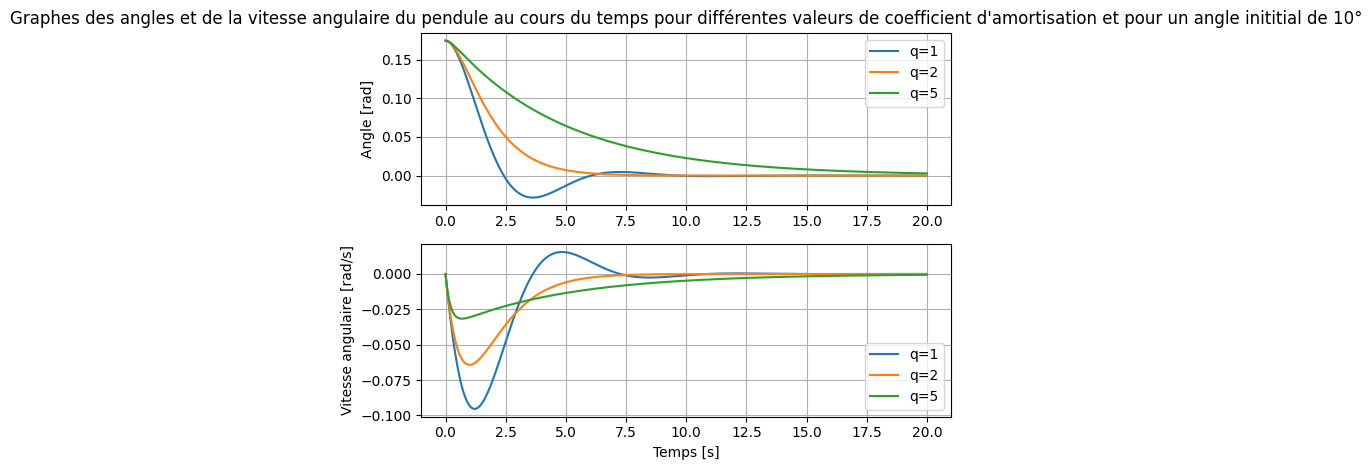

In [36]:
# Conditions initiales
u_ini = np.array([np.pi / 18, 0.0])

# Résolution numérique par méthode RK4 et traçage du graphe
for q in q_list:
    
    def derivee_u_q(u, t): 
        return derivee_u(u, t, q)
    
    t, u = RK4(0, 20, 0.05, u_ini, derivee_u_q)

    # Tracer l'angle et la vitesse angulaire pour chaque q
    plt.subplot(2, 1, 1)
    plt.plot(t, u[0, :], label=f'q={q}')
    plt.ylabel('Angle [rad]')
    plt.grid()

    plt.subplot(2, 1, 2)
    plt.plot(t, u[1, :], label=f'q={q}')
    plt.ylabel('Vitesse angulaire [rad/s]')
    plt.xlabel('Temps [s]')
    plt.grid()

# Ajouter une légende

plt.subplot(2, 1, 1)
plt.legend()
plt.title("Graphes des angles et de la vitesse angulaire du pendule au cours du temps pour différentes valeurs de coefficient d'amortisation et pour un angle inititial de 10°")
plt.subplot(2, 1, 2)
plt.legend()

# Afficher les graphiques
plt.tight_layout()
plt.show()

### Discussion des résultats

Nous remarquons qu'en fonction de la valeur du coefficient d'amortisation, l'allure de la courbe qui décrit l'angle du pendule en fonction du temps change.

Pour le cas $q=1$, la courbe caractérise une situation 'pseudo-périodique'. On a plusieurs oscillations autour de la position d'équilibre. La position d'équilibre est atteinte après plusieurs oscillations. 

Pour le cas $q=2$, la courbe caractérise une situation 'critique'. On a pas d'oscillations autour de la position d'équilibre. La position d'équilibre est atteinte très rapidement.

Pour le cas $q=5$, la courbe caractérise une situation 'apériodique' ou 'sur-amortie'. On a pas d'oscillations autour de la position d'équilibre. La position d'équilibre est atteinte lentement.



### Résolution du problème du pendule avec force d'excitation

Nous modifions l'équation du mouvement du pendule amorti en y ajoutant une force d'excitation sinusoïdale. L'équation devient :  

$$
\frac{\mathrm{d}^2\theta}{\mathrm{d}t^2} + q\frac{\mathrm{d}\theta}{\mathrm{d}t} + \Omega^2 \theta = F_e \sin(\Omega_e t)
$$

où $F_e$ est l'intensité de la force d'excitation et $\Omega_e$ sa pulsation. Nous allons résoudre cette équation en utilisant la méthode de Runge-Kutta d'ordre 4 (RK4).

#### Transformation en système du premier ordre

Pour résoudre cette équation par la méthode RK4, nous procédons à la même transformation qu'auparavant en posant $\omega = \frac{\mathrm{d}\theta}{\mathrm{d}t}$, ce qui donne le système suivant :

$$
\frac{\mathrm{d}\theta}{\mathrm{d}t} = \omega, \quad \frac{\mathrm{d}\omega}{\mathrm{d}t} = -q\omega - \Omega^2 \theta + F_e \sin(\Omega_e t)
$$

#### Application de la méthode RK4

Nous appliquons la méthode de Runge-Kutta d'ordre 4 pour résoudre numériquement ce système en prenant un pas de temps $\Delta t$. Nous résolvons pour trois régimes différents :

1. **Pendule libre** ($q=0$, $F_e=0$) : il n'y a pas d'amortissement ni d'excitation externe.
2. **Pendule amorti** ($q=1$, $F_e=0$) : il y a un amortissement mais aucune excitation externe.
3. **Pendule amorti avec excitation** ($q=1$, $F_e=1$) : il y a à la fois un amortissement et une excitation externe avec une intensité de $F_e = 1\,\mathrm{rad\cdot s^{-2}}$ et une pulsation de $\Omega_e = \frac{2\Omega}{3}$.

#### Conditions initiales

Les conditions initiales sont les suivantes :

$$
\theta(t=0) = 10^\circ = \frac{10\pi}{180}\,\text{rad}, \quad \frac{\mathrm{d}\theta}{\mathrm{d}t}(t=0) = 0
$$

Le pas de temps est fixé à $\Delta t = 0.05\ \mathrm{s}$.

#### Tracé de la trajectoire dans l'espace des phases

Une fois la solution obtenue pour chaque cas, nous traçons la trajectoire dans l'espace des phases $\left(\theta, \frac{\mathrm{d}\theta}{\mathrm{d}t}\right)$ pour les trois régimes :

1. **Pendule libre** : Trajectoire sans amortissement ni excitation.
2. **Pendule amorti** : Trajectoire avec amortissement mais sans excitation.
3. **Pendule amorti avec excitation** : Trajectoire avec amortissement et excitation.

Ainsi, on pourra comparer l'effet de l'amortissement et de l'excitation sur la dynamique du pendule, en particulier sur la forme et la stabilité de la trajectoire dans l'espace des phases.


In [37]:
# Paramètres
L = 9.81 # Longueur (m)
g = 9.81 # Pesanteur (m.s^-2)
kp = np.sqrt(g / L)  # Pulsation (notée k dans l'énoncé)
ke = kp * 2/3
Fe_list = [0, 0, 1]
Tp = 2 * np.pi / kp # Période (s)
q_list = [0, 1, 1]

In [38]:
# Définition de la fonction dérivée
def derivee_u (u, t, q, Fe):
    '''
        Soit u = (u0, u1)
        Équation d'évolution du pendule : d(u0, u1)/dt = (u1, -k ** 2 * u0)
    '''
    # Initialisation de la dérivée
    du = np.empty(u.shape)
    
    # Dérivée de la vitesse
    du[0] = u[1]
    du[1] = -q * u[1] - kp ** 2 * u[0] + Fe * np.sin(ke * t)

    return du


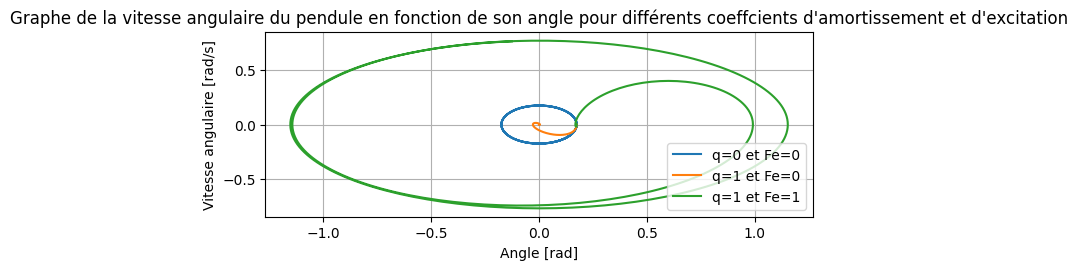

In [39]:
# Conditions initiales
u_ini = np.array([np.pi / 18, 0.0])

# # Résolution numérique par méthode RK4 et traçage du graphe
for i in range(len(q_list)):
    q = q_list[i]
    Fe = Fe_list[i]
    
    def derivee_u_q(u, t): 
        return derivee_u(u, t, q, Fe)
    
    t, u = RK4(0, 20, 0.05, u_ini, derivee_u_q)

    # Tracer l'angle et la vitesse angulaire pour chaque q
    plt.subplot(2, 1, 1)
    plt.plot(u[0, :], u[1, :], label=f'q={q} et Fe={Fe}')
    plt.xlabel('Angle [rad]')
    plt.ylabel('Vitesse angulaire [rad/s]')
    plt.grid()
    
# Ajouter une légende
plt.subplot(2, 1, 1)
plt.title("Graphe de la vitesse angulaire du pendule en fonction de son angle pour différents coeffcients d'amortissement et d'excitation")
plt.legend()

# Afficher les graphiques
plt.tight_layout()
plt.show()

### Discussion des résultats

Nous remarquons qu'en fonction de la valeur du coefficient d'amortisation et de la force d'excitation, l'allure de la courbe qui décrit l'angle du pendule en de sa vitesse angulaire change.

Pour le cas $q = 0$ et $F_e = 0$, la courbe caractérise une oscillation perpétuelle. Le pendule retrouve toujours son angle initial après une oscillation. On a des oscillations autour de la position d'angle nul. On vérifie le résultat connu de la conservation de l'énergie mécanique d'un système oscillant sans frottements: la norme de la vitesse angulaire est maximale pour la position où l'énergie potentielle est minimale ($\theta = 0$) et la norme de la vitesse angulaire est nulle pour la position où l'énergie potentielle est maximale. 

Pour le cas $q = 1$ et $F_e = 0$, la courbe caractérise la situation 'pseudo-périodique de la question précendente'. On vérifie les résultats trouvés précedement sous une autre forme, à savoir que le pendule oscille autour de la position d'équilibre et la retrouve après plusieurs oscillations. 

Pour le cas $q = 1$ et $F_e = 1$, la courbe caractérise une autre situation d'oscillation perpétuelle. Le pendule part d'un angle et s'en écarte sous l'influence de la force d'excitation. On a des oscillations autour de la position d'angle nul. Au bout de plusieurs oscillations, on trouve un régime d'équilibre stationnaire, ou la force d'excitation et de frottement se compense. On vérifie le résultat connu de la conservation de l'énergie mécanique d'un système oscillant en régime stationnaire: la norme de la vitesse angulaire est maximale pour la position où l'énergie potentielle est minimale ($\theta = 0$) et la norme de la vitesse angulaire est nulle pour la position où l'énergie potentielle est maximale. 

#### Résolution du problème du pendule non-linéaire avec excitation

Lorsque l'on ne fait plus l'hypothèse des petits angles ($\sin\theta \approx \theta$), l'équation du mouvement devient non-linéaire et s'écrit sous la forme :  

$$
\frac{\mathrm{d}^2\theta}{\mathrm{d}t^2} + q \frac{\mathrm{d}\theta}{\mathrm{d}t} + \Omega^2 \sin\theta = F_e \sin(\Omega_e t)
$$

Ce système peut conduire à un comportement chaotique sous certaines conditions. Nous allons résoudre cette équation avec la méthode de Runge-Kutta d'ordre 4 (RK4) pour plusieurs valeurs de l'amplitude de l'excitation, $F_e = \{1.4, 1.44, 1.465, 1.5\} \,\mathrm{rad \cdot s^{-2}}$.

## Transformation en système du premier ordre

Nous procédons à la même transformation qu'auparavant en posant $ \omega = \frac{\mathrm{d}\theta}{\mathrm{d}t} $, ce qui donne le système suivant :  

$$
\frac{\mathrm{d}\theta}{\mathrm{d}t} = \omega, \quad \frac{\mathrm{d}\omega}{\mathrm{d}t} = -q \omega - \Omega^2 \sin\theta + F_e \sin(\Omega_e t)
$$

#### Conditions initiales et paramètres

Les conditions initiales sont les suivantes :  

$$
\theta(t=0) = 10^\circ = \frac{10\pi}{180} \,\text{rad}, \quad \frac{\mathrm{d}\theta}{\mathrm{d}t}(t=0) = 0
$$

Les paramètres sont :  
- $q = 0.5 \,\mathrm{s^{-1}}$
- $\Omega_e = \frac{2\Omega}{3}$
- L'amplitude de l'excitation varie : $F_e = \{1.4, 1.44, 1.465, 1.5\} \,\mathrm{rad \cdot s^{-2}}$

Nous allons tracer $\theta(t)$ pour un temps de $100 \,\mathrm{s}$.

#### Application de la méthode RK4

Nous appliquons la méthode de Runge-Kutta d'ordre 4 pour résoudre ce système à chaque instant $t$ en prenant un pas de temps $\Delta t$. 

#### Trajectoires pour différentes amplitudes d'excitation

Nous traçons les courbes $\theta(t)$ pour les différentes valeurs de $F_e$ afin d'étudier l'impact de l'amplitude de l'excitation sur le comportement du pendule.  

#### Comportement périodique et chaotique

Nous analysons l'évolution de $\theta(t)$ pour les différentes amplitudes d'excitation et nous constatons que lorsque $F_e$ approche certaines valeurs critiques, le comportement du pendule devient chaotique. En particulier, au-delà de $F_e = 1.465$, le système présente un comportement de plus en plus sensible aux conditions initiales.

#### Test avec des conditions initiales très proches

Dans le cas $F_e = 1.5 \,\mathrm{rad \cdot s^{-2}}$, nous calculons l'évolution de $\theta(t)$ pour deux conditions initiales très proches :

- $\theta(t=0) = 10^\circ$
- $\theta(t=0) = 9.999^\circ$

Nous traçons la valeur absolue de la différence entre les deux solutions, $|\theta_1(t) - \theta_2(t)|$, en fonction du temps sur une échelle semi-logarithmique. Ce test nous permet d'illustrer le caractère chaotique du système, où une petite différence initiale conduit à une divergence exponentielle des solutions.


In [40]:
# Paramètres
L = 9.81 # Longueur (m)
g = 9.81 # Pesanteur (m.s^-2)
kp = np.sqrt(g / L)  # Pulsation (notée k dans l'énoncé)
ke = kp * 2/3
Fe_list = [1.4, 1.44, 1.465, 1.5]
Tp = 2 * np.pi / kp # Période (s)
q = 0.5

In [41]:
# Définition de la fonction dérivée
def derivee_u (u, t, q, Fe):
    '''
        Soit u = (u0, u1)
        Équation d'évolution du pendule : d(u0, u1)/dt = (u1, -k ** 2 * u0)
    '''
    # Initialisation de la dérivée
    du = np.empty(u.shape)
    
    # Dérivée de la vitesse
    du[0] = u[1]
    du[1] = -q * u[1] - kp ** 2 * np.sin(u[0]) + Fe * np.sin(ke * t)

    return du

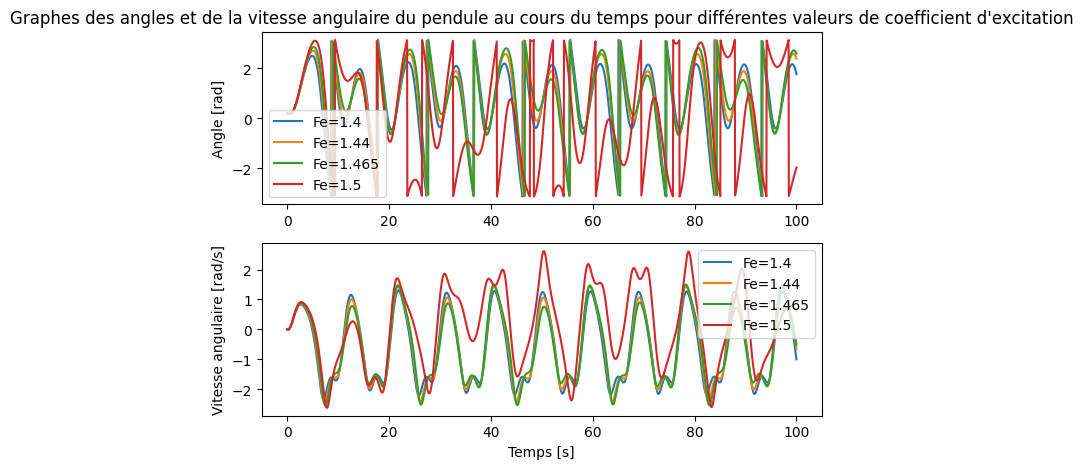

In [42]:
# Conditions initiales
u_ini = np.array([np.pi / 18, 0.0])

# Résolution numérique par méthode RK4 et traçage des graphes

for i in range(len(Fe_list)):
    Fe = Fe_list[i]
    
    def derivee_u_q(u, t): 
        return derivee_u(u, t, q, Fe)
    
    t, u = RK4(0, 100, 0.05, u_ini, derivee_u_q)
    
    for j in range(len(t)):
        # Si l'angle dépasse pi, on le ramène dans l'intervalle [-pi, pi]
        modulo = u[0, j] / np.pi
        if modulo > 1:
            u[0, j] -= np.round(0.5*np.abs(modulo)) * 2 * np.pi  # Réduire de 2pi pour le ramener dans l'intervalle
        elif modulo < -1:
            u[0, j] += np.round(0.5*np.abs(modulo)) * 2 * np.pi  # Ajouter 2pi pour le ramener dans l'intervalle
    
    # Tracer l'angle et la vitesse angulaire pour chaque q
    plt.subplot(2, 1, 1)
    plt.plot(t, u[0, :], label=f'Fe={Fe}')
    plt.ylabel('Angle [rad]')
    plt.grid()

    plt.subplot(2, 1, 2)
    plt.plot(t, u[1, :], label=f'Fe={Fe}')
    plt.ylabel('Vitesse angulaire [rad/s]')
    plt.xlabel('Temps [s]')
    plt.grid()
    

# Ajouter une légende
plt.subplot(2, 1, 1)
plt.title("Graphes des angles et de la vitesse angulaire du pendule au cours du temps pour différentes valeurs de coefficient d'excitation")
plt.legend()

plt.subplot(2, 1, 2)
plt.legend()

# Afficher les graphiques
plt.tight_layout()
plt.show()

### Discussion des résultats

Nous remarquons que la période du pendule observée sur les graphes de l'angle ou de la vitesse angulaire en fonction du temps montre un comportement globalement périodique pour des valeurs de coefficient d'excitation entre 1.4 et 1.465. La valeur de la période est très proche et stable au cours du temps. Nous remarquons que pour un coefficient d'excitation égal a 1.5, la période du pendule s'écarte des autres à partir de t=20s, et le comprtement de l'angle du pendule devient chaotique à partir de ce temps.  

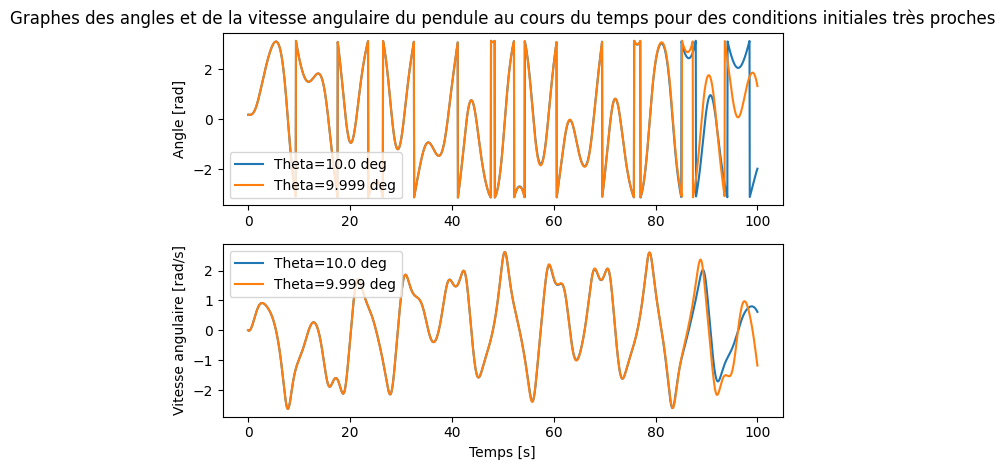

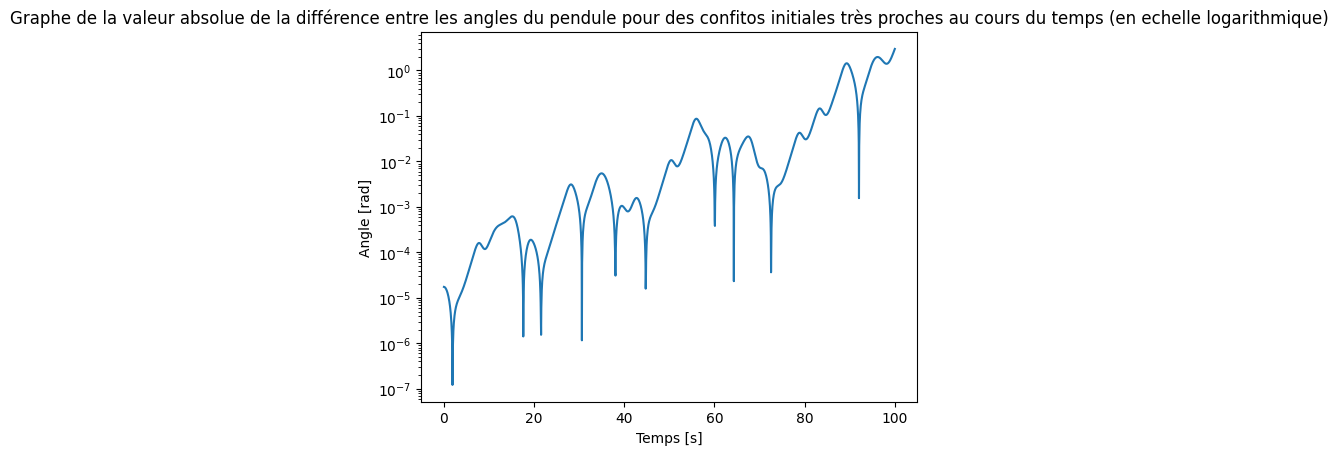

In [43]:
# Conditions initiales
u_ini_list = [np.array([np.pi / 18, 0.0]), np.array([9.999 * np.pi / 180, 0.0])]

# Méthode RK4

def derivee_u_q(u, t): 
    return derivee_u(u, t, q, Fe)
    
for i in range(len(u_ini_list)):
    u_ini = u_ini_list[i]
    
    def derivee_u_q(u, t): 
        return derivee_u(u, t, q, Fe)
    
    t, u = RK4(0, 100, 0.05, u_ini, derivee_u_q)
    
    for j in range(len(t)):
        # Si l'angle dépasse pi, on le ramène dans l'intervalle [-pi, pi]
        modulo = u[0, j] / np.pi
        if modulo > 1:
            u[0, j] -= np.round(0.5*np.abs(modulo)) * 2 * np.pi  # Réduire de 2pi pour le ramener dans l'intervalle
        elif modulo < -1:
            u[0, j] += np.round(0.5*np.abs(modulo)) * 2 * np.pi  # Ajouter 2pi pour le ramener dans l'intervalle
    
    # Tracer l'angle et la vitesse angulaire pour chaque q
    plt.subplot(2, 1, 1)
    plt.plot(t, u[0, :], label=f'Theta={u_ini_list[i][0]*180/np.pi} deg')
    plt.ylabel('Angle [rad]')
    plt.grid()

    plt.subplot(2, 1, 2)
    plt.plot(t, u[1, :], label=f'Theta={u_ini_list[i][0]*180/np.pi} deg')
    plt.ylabel('Vitesse angulaire [rad/s]')
    plt.xlabel('Temps [s]')
    plt.grid()

# Ajouter une légende
plt.subplot(2, 1, 1)
plt.title("Graphes des angles et de la vitesse angulaire du pendule au cours du temps pour des conditions initiales très proches")
plt.legend()

plt.subplot(2, 1, 2)
plt.legend()

# Afficher les graphiques
plt.tight_layout()
plt.show()

t, u = RK4(0, 100, 0.05, u_ini_list[0], derivee_u_q)
t1, u1 = RK4(0, 100, 0.05, u_ini_list[1], derivee_u_q)

diff = np.abs(u1[0,:] - u[0,:])
plt.semilogy(t, diff)
plt.title('Graphe de la valeur absolue de la différence entre les angles du pendule pour des confitos initiales très proches au cours du temps (en echelle logarithmique)')
plt.xlabel('Temps [s]')
plt.ylabel('Angle [rad]')
plt.show()

### Discussion des résultats

Nous traçons la courbe de la valeur absolue de la différence entre les angles du pendules pour un coefficient d'excitation égal a 1.5 et des angles de départ très proches. Nous remarquons que la différence croit de manière exponentielle avec le temps. Ceci montre que m^eme pour des valeurs de départ très proches, le comportement chaotique associé au coefficient d'excitation $F_e = 1.5$ se retrouve pour un temps suffisament long. 


# Conclusion

Ce mini-projet nous a permis d'explorer la dynamique d'un pendule amorti et excité, en abordant à la fois les aspects linéaires et non-linéaires du système. Nous avons utilisé la méthode de Runge-Kutta d'ordre 4 (RK4) pour résoudre numériquement les équations du mouvement dans différents régimes. Tout d'abord, nous avons étudié le pendule linéaire avec amortissement, puis nous avons ajouté une excitation externe, observant comment cela influençait la trajectoire du système, en particulier dans l'espace des phases.

Nous avons ensuite pris en compte la non-linéarité du système en supprimant l'hypothèse des petits angles, ce qui a conduit à une équation différentielles non-linéaire. Cette partie du projet a mis en lumière des comportements complexes, notamment un phénomène chaotique pour certaines valeurs des paramètres. Nous avons observé que, dans le cas de valeurs proches de la résonance, le système devenait extrêmement sensible aux conditions initiales, caractéristique du chaos.

Les résultats ont permis de mieux comprendre l'impact de l'amortissement, de l'excitation et de la non-linéarité sur le comportement du pendule. En particulier, l'analyse du comportement chaotique a souligné l'importance de la précision des conditions initiales et la nécessité de méthodes numériques robustes comme RK4 pour étudier ces systèmes complexes.

En conclusion, ce projet a illustré la richesse de la dynamique des systèmes non-linéaires et l'importance de la méthode RK4 pour leur résolution. L'étude du pendule a permis d'illustrer des phénomènes allant de l'oscillation périodique au chaos, fournissant une compréhension plus profonde des comportements dynamiques dans des systèmes physiques réels.
